# 5 — Risk Assessment

**Mandatory Task C**: Evaluate historical risk for individual stocks.

Metrics:
- Annualized Volatility
- Sharpe Ratio
- Sortino Ratio
- Maximum Drawdown
- Value at Risk (VaR, 95%)
- Conditional VaR / Expected Shortfall

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.preprocess import load_all_stocks, load_metadata
from src.preprocess import RISK_FREE_RATE, TRADING_DAYS

sns.set_style('whitegrid')
%matplotlib inline

## 5.1 Compute Risk Metrics for All Stocks

In [2]:
stocks = load_all_stocks()
meta = load_metadata()

def compute_risk(df):
    """Risk metrics for one stock."""
    ret = df['Close'].pct_change().dropna()
    ann_ret = ret.mean() * TRADING_DAYS
    ann_vol = ret.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0

    down = ret[ret < 0]
    down_std = down.std() * np.sqrt(TRADING_DAYS) if len(down) > 0 else 1e-9
    sortino = (ann_ret - RISK_FREE_RATE) / down_std

    cum = (1 + ret).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

    var95 = np.percentile(ret, 5)
    cvar95 = ret[ret <= var95].mean()

    return {
        'ann_return': ann_ret, 'ann_volatility': ann_vol,
        'sharpe': sharpe, 'sortino': sortino,
        'max_drawdown': max_dd, 'VaR_95': var95, 'CVaR_95': cvar95,
    }

rows = []
for sym, df in stocks.items():
    m = compute_risk(df)
    m['symbol'] = sym
    m['sector'] = meta.loc[sym, 'Industry'] if sym in meta.index else 'Unknown'
    rows.append(m)

risk_table = pd.DataFrame(rows).set_index('symbol').sort_values('sharpe', ascending=False)
risk_table.style.format('{:.4f}', subset=[c for c in risk_table.columns if c != 'sector'])

,ann_return,ann_volatility,sharpe,sortino,max_drawdown,VaR_95,CVaR_95,sector
symbol,,,,,,,,
SHREECEM,0.3823,0.3897,0.8143,1.2767,-0.7997,-0.0354,-0.0510,CEMENT & CEMENT PRODUCTS
BAJFINANCE,0.3899,0.4866,0.6677,0.8005,-0.9328,-0.0385,-0.0630,FINANCIAL SERVICES
BAJAJFINSV,0.3231,0.4009,0.6439,0.9054,-0.8679,-0.0349,-0.0557,FINANCIAL SERVICES
MARUTI,0.2684,0.3448,0.5900,0.8768,-0.6134,-0.0317,-0.0476,AUTOMOBILE
EICHERMOT,0.3470,0.4804,0.5871,0.7290,-0.9382,-0.0373,-0.0596,AUTOMOBILE
ULTRACEMCO,0.2490,0.3326,0.5530,0.8480,-0.7778,-0.0306,-0.0450,CEMENT & CEMENT PRODUCTS
NESTLEIND,0.1979,0.2423,0.5488,0.8591,-0.3240,-0.0215,-0.0321,CONSUMER GOODS
INDUSINDBK,0.3078,0.5071,0.4789,0.6398,-0.8511,-0.0416,-0.0698,FINANCIAL SERVICES
TITAN,0.3040,0.5000,0.4781,0.5826,-0.9669,-0.0405,-0.0636,CONSUMER GOODS


## 5.2 Top and Bottom Stocks by Sharpe

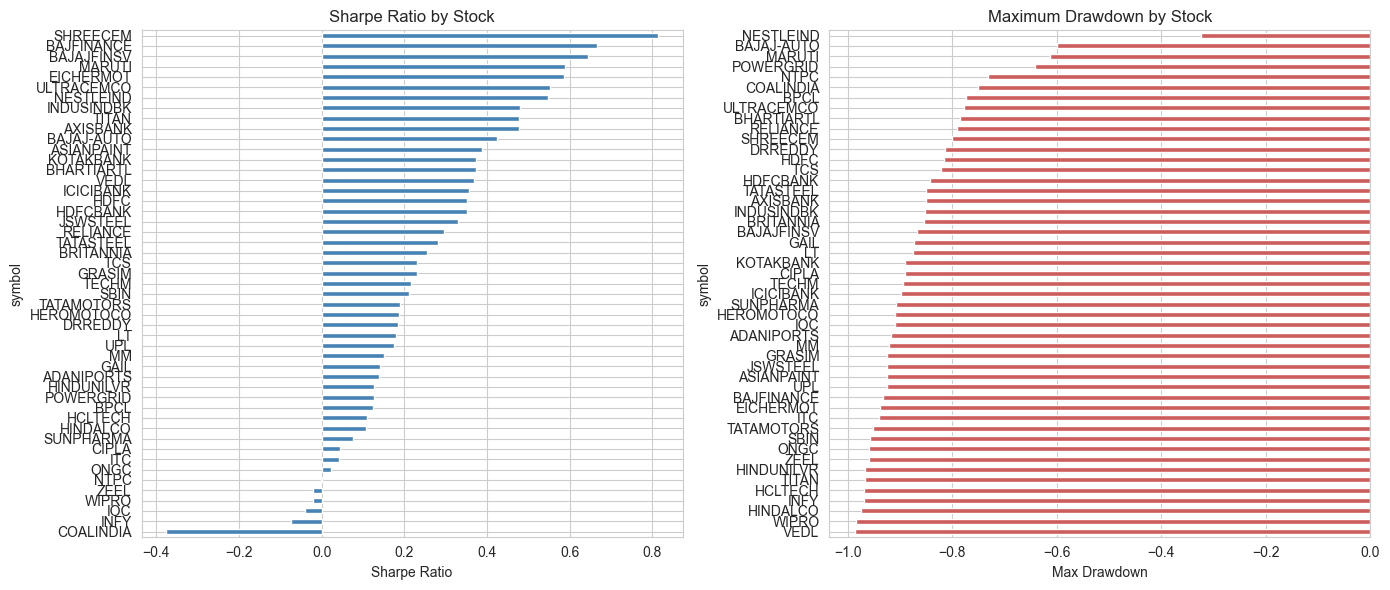

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

risk_table['sharpe'].sort_values(ascending=True).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Sharpe Ratio by Stock')
axes[0].set_xlabel('Sharpe Ratio')

risk_table['max_drawdown'].sort_values().plot.barh(ax=axes[1], color='indianred')
axes[1].set_title('Maximum Drawdown by Stock')
axes[1].set_xlabel('Max Drawdown')

plt.tight_layout()
plt.show()

## 5.3 Risk–Return Scatter

In [5]:
fig = px.scatter(
    risk_table.reset_index(),
    x='ann_volatility',
    y='ann_return',
    text='symbol',
    color='sharpe',
    color_continuous_scale='RdYlGn',
    hover_data=['sector'],
    title='Risk vs Return — All NIFTY-50 Stocks',
    labels={
        'ann_volatility': 'Annualized Volatility',
        'ann_return': 'Annualized Return'
    }
)

fig.update_traces(textposition='top center')
fig.show()

## 5.4 Drawdown Analysis — Example Stock

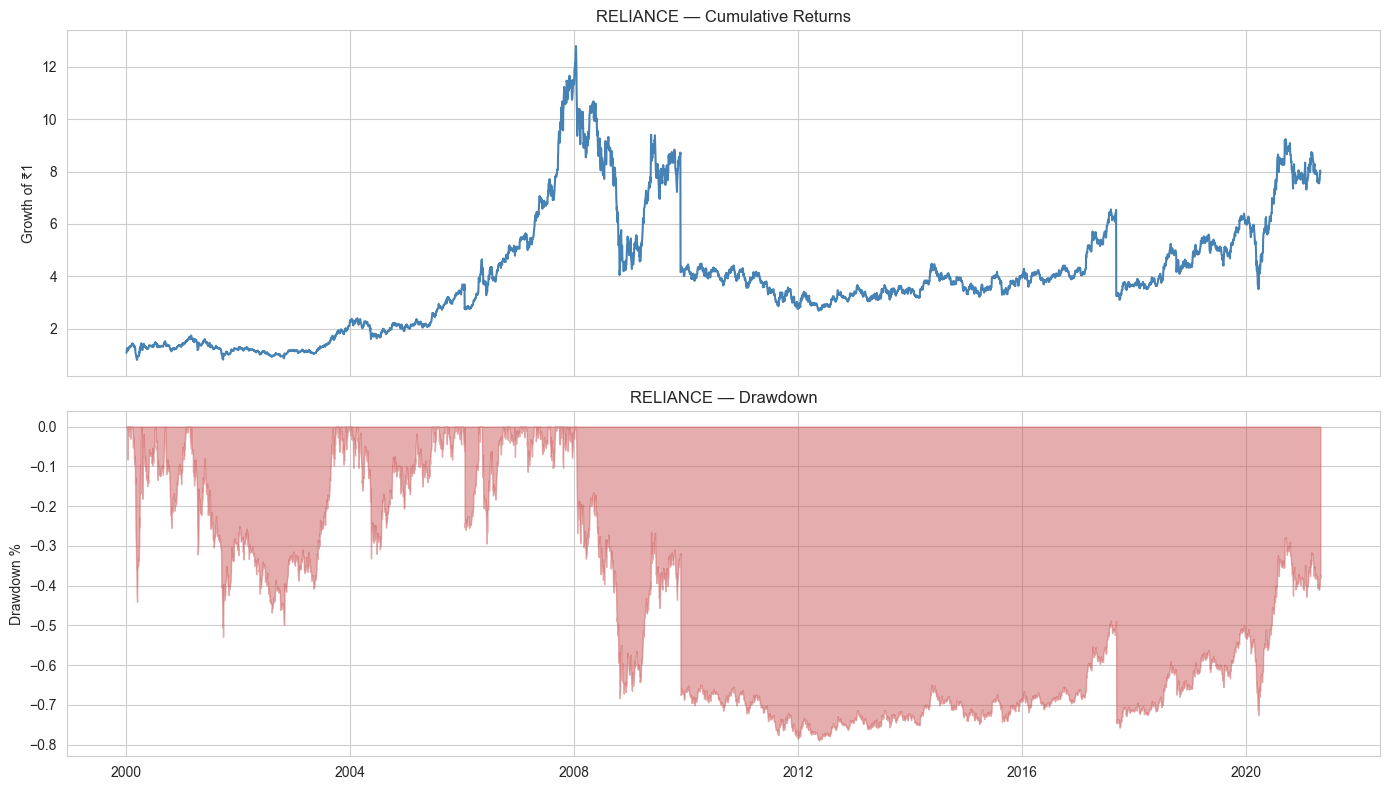

Max Drawdown: -0.7901
Worst Drawdown Date: 2012-05-16 00:00:00


In [6]:
sym = 'RELIANCE'
ret = stocks[sym]['Close'].pct_change().dropna()
cum = (1 + ret).cumprod()
drawdown = (cum - cum.cummax()) / cum.cummax()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(cum, color='steelblue')
axes[0].set_title(f'{sym} — Cumulative Returns')
axes[0].set_ylabel('Growth of ₹1')

axes[1].fill_between(drawdown.index, drawdown.values, 0, color='indianred', alpha=0.5)
axes[1].set_title(f'{sym} — Drawdown')
axes[1].set_ylabel('Drawdown %')

plt.tight_layout()
plt.show()

print(f'Max Drawdown: {drawdown.min():.4f}')
print(f'Worst Drawdown Date: {drawdown.idxmin()}')

## 5.5 Sector-Level Risk

In [7]:
sector_risk = risk_table.groupby('sector').agg({
    'ann_return': 'mean',
    'ann_volatility': 'mean',
    'sharpe': 'mean',
    'max_drawdown': 'mean',
}).sort_values('sharpe', ascending=False)

sector_risk.style.format('{:.4f}')

,ann_return,ann_volatility,sharpe,max_drawdown
sector,,,,
CEMENT & CEMENT PRODUCTS,0.2625,0.3726,0.5326,-0.8339
FINANCIAL SERVICES,0.2641,0.4551,0.4350,-0.8781
TELECOM,0.2143,0.3999,0.3732,-0.7847
AUTOMOBILE,0.2085,0.4137,0.3547,-0.8223
CONSUMER GOODS,0.1745,0.3636,0.3066,-0.8293
CONSTRUCTION,0.1387,0.4094,0.1800,-0.8753
FERTILISERS & PESTICIDES,0.1486,0.4771,0.1752,-0.9253
METALS,0.1543,0.4605,0.1428,-0.8970
SERVICES,0.1325,0.4821,0.1400,-0.9174


In [8]:
fig = px.bar(sector_risk.reset_index(), x='sector', y='sharpe',
             color='ann_volatility', title='Avg Sharpe Ratio by Sector')
fig.show()

## 5.6 Value at Risk Distribution

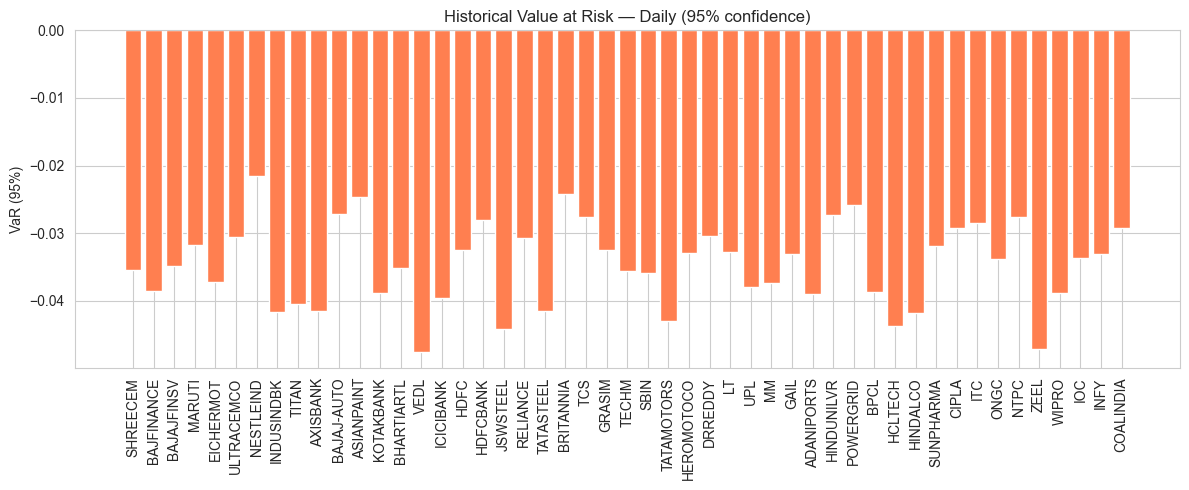

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(risk_table.index, risk_table['VaR_95'], color='coral')
ax.set_ylabel('VaR (95%)')
ax.set_title('Historical Value at Risk — Daily (95% confidence)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5.7 Key Findings

- Stocks with **higher annualized returns** generally have **higher volatility** (risk-return tradeoff)
- **Maximum drawdowns** of 50–80% are common across most stocks (market-wide crashes like 2008, 2020)
- **Banking stocks** tend to have higher volatility; **Consumer/Pharma** tend to be more stable
- **VaR (95%)** shows daily loss thresholds between 2–5% for most stocks
- Sharpe ratios help identify stocks that reward risk well vs. those with high volatility but low returns